In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt
from matplotlib import colormaps

sys.path.append("C:/Users/haoyu/Documents/GitHub/XRaySimulation")

from XRaySimulation import Pulse, DeviceSimu, util, Crystal

In [2]:
bLattice = np.zeros((11, 11, 11, 360, 3))

bLattice[:,:,:,:,0] = np.arange(-5, 6)[:, np.newaxis, np.newaxis, np.newaxis] * np.pi * 2 / 5.6578 * 1e4
bLattice[:,:,:,:,1] = np.arange(-5, 6)[np.newaxis, :, np.newaxis, np.newaxis] * np.pi * 2 / 5.6578 * 1e4
bLattice[:,:,:,:,2] = np.arange(-5, 6)[np.newaxis, np.newaxis, :, np.newaxis] * np.pi * 2 / 5.6578 * 1e4

tilt_angle = np.deg2rad(-5)
tilt_mat = np.array([
    [1, 0, 0,],
    [0, np.cos(tilt_angle), -np.sin(tilt_angle)],
    [0, np.sin(tilt_angle), np.cos(tilt_angle)],
])

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            for idx in range(360):
                angle = np.deg2rad(idx)
                rot_mat = np.array([[np.cos(angle), 0, -np.sin(angle)],
                                    [0, 1, 0],
                                    [np.sin(angle), 0, np.cos(angle)],])
                
                bLattice[xIdx, yIdx, zIdx, idx, :] = np.dot(tilt_mat, np.dot(rot_mat, bLattice[xIdx, yIdx, zIdx, idx]))

In [3]:
kLen = util.kev_to_wavevec_length(9.8)
angle = np.deg2rad(11.639) * 2
kvec = np.array([-np.sin(angle), 0, np.cos(angle)]) * kLen

tg_angle = np.deg2rad(0.7)
kvec_tg = np.copy(kvec)
kvec_tg[1] += 2 * np.sin(tg_angle) * kLen

In [4]:
kout = bLattice + kvec_tg[np.newaxis, np.newaxis, np.newaxis, np.newaxis]
kout_len = np.linalg.norm(kout, axis=-1)
kout_len_diff = kout_len - kLen

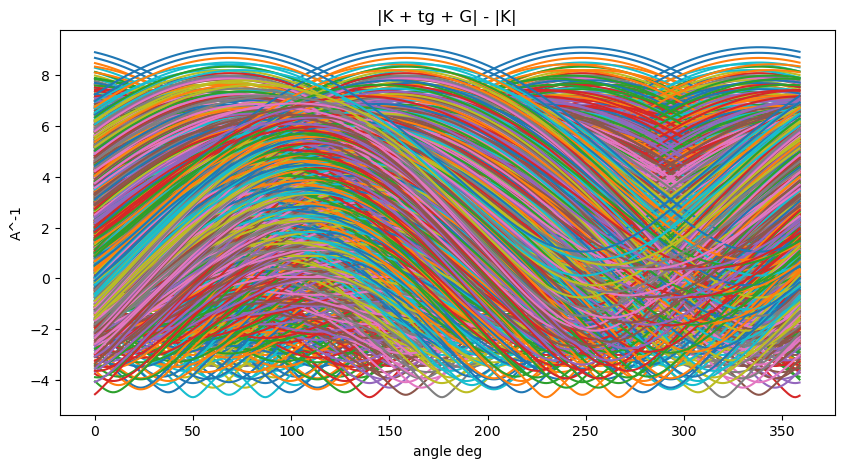

In [5]:
fig, ax = plt.subplots(ncols=1,nrows=1)
cmap = colormaps['summer']

fig.set_figheight(5)
fig.set_figwidth(10)

for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            ax.plot(np.arange(360), kout_len_diff[xIdx, yIdx, zIdx] / 1e4,
                    label="G=({}, {}, {})".format(xIdx, yIdx, zIdx))

plt.title('|K + tg + G| - |K|')
plt.ylabel("A^-1")
plt.xlabel('angle deg')
#plt.legend()
plt.show()

In [29]:
for xIdx in range(11):
    for yIdx in range(11):
        for zIdx in range(11):
            x = np.argmin(np.abs(kout_len_diff[xIdx, yIdx, zIdx] / 1e4))
            k_tmp = kout[xIdx, yIdx, zIdx, x]

            if x == 359:
                continue
                
            if kout_len_diff[xIdx, yIdx, zIdx, x - 1] *  kout_len_diff[xIdx, yIdx, zIdx, x + 1] < 0:

                flag1 = (abs(xIdx - 5) % 2 == 1) and (abs(yIdx - 5) % 2 == 1) and (abs(zIdx - 5) % 2 == 1)
                flag2 = (abs(xIdx - 5) % 2 == 0) and (abs(yIdx - 5) % 2 == 0) and (abs(zIdx - 5) % 2 == 0)
                flag2 = flag2 and (abs(xIdx + yIdx + zIdx - 15) % 4 != 2)

                if flag1 or flag2:
                    #print(xIdx, yIdx, zIdx)

                    if k_tmp[0] > 0 and k_tmp[1] > 0 and k_tmp[2] > 0:
                
                        # Normalize the wave-vector
                        direction = k_tmp / np.linalg.norm(k_tmp)
                
                        # Get the position
                        position = direction / direction[2] * 12

                        # Impose the det position limitation
                        if position[0] < 18 and position[1]<14:
                            
                            if xIdx - 5 >= 0 and yIdx - 5>= 0 and zIdx - 5>= 0 :

                                print("G=({}, {}, {})".format(xIdx - 5, yIdx - 5, zIdx - 5), kout[xIdx, yIdx, zIdx, x], x + 1)
                                print("detector positoin with respect to the sample in cm", position)
                                print('------------------------------')

G=(0, 2, 2) [ 2583.93965636 23339.66736371 43685.25130041] 271
detector positoin with respect to the sample in cm [ 0.7097882   6.41122576 12.        ]
------------------------------
G=(1, 1, 3) [15478.34018219 12360.170875   45608.64136019] 291
detector positoin with respect to the sample in cm [ 4.07247567  3.25206027 12.        ]
------------------------------
G=(1, 1, 5) [35697.71960627 11224.36773279 32626.35203917] 270
detector positoin with respect to the sample in cm [13.1296516   4.12833199 12.        ]
------------------------------
G=(2, 0, 2) [11664.38628682  1452.08379693 48348.24471858] 321
detector positoin with respect to the sample in cm [ 2.89509239  0.36040617 12.        ]
------------------------------
G=(2, 2, 0) [ 2583.93965636 23339.66736371 43685.25130041] 1
detector positoin with respect to the sample in cm [ 0.7097882   6.41122576 12.        ]
------------------------------
G=(3, 1, 1) [15480.42762085 12353.22316204 45529.22863772] 344
detector positoin with r

In [27]:
6 % 4

2